In [16]:
import requests
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

In [34]:
#Load the processed data set

final_df=pd.read_csv("C:/Users/abrup\Desktop\Project/survival-analysis/data/processed/brca_final_processed.csv")

In [4]:
final_df

,Patient_ID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6,Time,Event
0,TCGA-BH-A209,2044,27,3098,1851,1891,1754,5515,5997,4661,...,42,0,0,0,671,0,17,37,3959.0,1
1,TCGA-B6-A0IH,6786,14,1381,2134,628,433,5024,2068,1462,...,12,0,1,0,517,0,16,15,2965.0,1
2,TCGA-D8-A1XC,402,1,1146,1236,264,122,532,1616,3909,...,1,0,0,1,419,0,0,19,377.0,1
3,TCGA-EW-A1P8,5262,17,1908,795,1045,1055,696,3727,2470,...,14,0,0,0,304,0,6,32,239.0,1
4,TCGA-BH-A1F6,7064,1899,2680,1626,527,1235,27487,3534,4535,...,42,0,1,2,645,0,12,7,2965.0,1
5,TCGA-E9-A1N6,3106,771,1525,887,249,833,4736,1365,1918,...,13,0,0,0,295,0,13,10,678.0,1
6,TCGA-B6-A0IC,1100,1,2200,2375,779,284,103,2047,4247,...,58,0,0,0,330,0,8,39,0.0,1
7,TCGA-BH-A1EW,2690,27,2435,2226,945,571,4785,1725,1871,...,20,0,0,0,729,0,13,7,1694.0,1
8,TCGA-BH-A18V,3116,817,1408,954,125,461,2454,1871,1038,...,26,0,0,0,253,0,16,25,1556.0,1
9,TCGA-AC-A23H,7324,231,1806,1385,337,470,13491,3061,2356,...,31,0,0,0,498,0,4,6,0.0,1


In [5]:
print(final_df.shape)
print(final_df.isna().sum().sum())
print(final_df.columns.duplicated().sum())

(41, 60663)
0
0


In [6]:
print(final_df.shape)
print(final_df.columns[:5])
print(final_df.columns[-5:])

(41, 60663)
Index(['Patient_ID', 'TSPAN6', 'TNMD', 'DPM1', 'SCYL3'], dtype='object')
Index(['AC006486.3', 'AL391628.1', 'AP006621.6', 'Time', 'Event'], dtype='object')


In [7]:
final_df = final_df.rename(columns={
    "Patient_ID": "patient_id",
    "Time": "time",
    "Event": "event"
})

# Feature Selection

In [8]:
#we need X and Y  .X is the input(features) and Y is output (Target)
X=final_df.drop(columns=["patient_id","time","event"])
y_time=final_df["time"]
y_event=final_df["event"]

In [9]:
#Removing genes that are not usefull or dont have much variations using a threshold vale

selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)

print("Reduced shape:", X_reduced.shape)
variances = X.var()

print(variances.describe())

Reduced shape: (41, 52509)
count    6.066000e+04
mean     3.086846e+07
std      1.330461e+09
min      0.000000e+00
25%      1.402439e-01
50%      7.422561e+00
75%      1.467502e+04
max      2.061332e+11
dtype: float64


In [10]:
#selected to 500 genes 
top_genes = X.var().sort_values(ascending=False).head(500).index

X_reduced = X[top_genes]

print(X_reduced.shape)

(41, 500)


In [11]:
variance=X_reduced.var()
print(variance.describe())

count    5.000000e+02
mean     3.538118e+09
std      1.423868e+10
min      1.554601e+08
25%      2.327547e+08
50%      4.440510e+08
75%      1.242691e+09
max      2.061332e+11
dtype: float64


In [12]:
X_reduced

,MT-CO1,MT-RNR2,MT-ND4,COL1A1,IGHG1,COL1A2,IGFBP5,COL3A1,MT-CO3,FN1,...,LRATD2,RPL14,NAA50,RPS7,S100A8,JUN,PTTG1IP,ALG8,ENAH,KTN1
0,449911,283742,828901,145685,1162071,137491,222448,157945,233520,415159,...,8839,69632,18218,61499,535,6106,23149,8583,24738,25751
1,289279,153101,219189,519546,472082,374169,44938,435951,218056,101285,...,4806,17910,5671,14316,66,9706,25073,1918,15556,11371
2,477310,250608,334322,15459,232,16674,2523,12436,185685,46089,...,8492,16884,6147,10171,25,13759,15417,2188,5559,17648
3,342001,224297,330131,164516,52885,133054,8916,104417,235650,123113,...,4190,21465,14279,35901,1213,10371,44258,2741,26482,12601
4,1235972,771921,1465953,90918,2242,141592,98124,127756,668745,107488,...,6862,28487,12649,28981,703,10113,19692,3328,16179,28222
5,329595,194436,373679,24168,19389,42432,33410,31587,203183,19345,...,3629,28123,7105,20605,112,41023,13049,1491,8811,14659
6,517895,611573,538597,20815,1478,15202,107522,10511,667810,40605,...,13888,35812,13312,22493,11,3229,25894,3629,13492,51336
7,430153,481994,239398,87717,30212,100188,30831,99087,175664,151739,...,6305,13581,7917,14353,510,6460,17011,1957,21865,22922
8,270574,373138,285422,81552,7260,114372,18637,94766,245635,12404,...,2329,55940,3720,53431,402,41209,13868,2067,3071,6198
9,1142085,787597,1048556,126855,7456,223696,202760,146089,643527,62782,...,4938,57206,10413,47129,890,5894,22900,2718,12609,21403


In [13]:
y_time

0     3959.0
1     2965.0
2      377.0
3      239.0
4     2965.0
5      678.0
6        0.0
7     1694.0
8     1556.0
9        0.0
10     336.0
11    2348.0
12    2273.0
13    2127.0
14    3669.0
15    1072.0
16     639.0
17     224.0
18     385.0
19    3461.0
20    3462.0
21     468.0
22     614.0
23     548.0
24    2712.0
25     883.0
26     172.0
27     811.0
28     825.0
29    2417.0
30    1009.0
31    1468.0
32    1430.0
33     584.0
34    3926.0
35    2483.0
36    3873.0
37    1275.0
38    2373.0
39    1439.0
40       1.0
Name: time, dtype: float64

In [14]:
y_event

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
Name: event, dtype: int64

In [15]:
print(X.index.equals(y_time.index))
print(X.index.equals(y_event.index))   #check both are from same patient

True
True


In [17]:
X_reduced = np.log1p(X_reduced)  #reduce the big numbers to small numbers

In [19]:
#looking for top 500 genes influence the most
analysis_df = X_reduced.copy()
analysis_df['Survival_Time'] = final_df['time']
correlations = analysis_df.corr()['Survival_Time'].drop('Survival_Time')
top_links = correlations.abs().sort_values(ascending=False).head(10)
print(" The 10 Genes most linked to Survival Time:")
print(correlations[top_links.index])

 The 10 Genes most linked to Survival Time:
RAB31        0.463519
CD44         0.460856
GSTP1       -0.460619
RAB11FIP1    0.448375
CELSR2       0.443935
GPRC5A       0.435124
WWP1         0.424727
IFITM3       0.423652
AZIN1        0.422693
DHRS2        0.418104
Name: Survival_Time, dtype: float64


### **Cox Proportional Hazards Model L1 penalty (LASSO)**


In [ ]:


# 
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_reduced)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_reduced.columns, index=X_reduced.index)

# 2. Re-combine for the model
df_model = X_scaled.copy()
df_model["time"] = y_time
df_model["event"] = y_event

# 3. Use HIGHER penalties (Start strict to keep the model stable)
penalties = [0.1, 0.5, 1.0, 5.0]

best_score = 0
for p in penalties:
    try:
        # Increase step_size or change the solver if it still struggles
        cph = CoxPHFitter(penalizer=p, l1_ratio=1.0)
        cph.fit(df_model, duration_col="time", event_col="event")
        
        score = cph.concordance_index_
        print(f"✅ Penalizer={p}, C-index={score:.3f}")
        
        if score > best_score:
            best_score = score
            best_model = cph
    except Exception as e:
        print(f" Penalizer={p} failed: The math was too complex.")

print("\nBest model score:", best_score)

✅ Penalizer=0.1, C-index=0.853
✅ Penalizer=0.5, C-index=0.622
✅ Penalizer=1.0, C-index=0.682
✅ Penalizer=5.0, C-index=0.682

Best model score: 0.8533007334963325


In [21]:
selected = best_model.summary.reindex(                                                      #coef > 0  → higher risk (bad survival)
                                                                                            #coef < 0  → protective (good survival)
    best_model.summary["coef"].abs().sort_values(ascending=False).index
)

top_genes = selected.head(20)

print(top_genes[["coef", "p"]])

               coef         p
covariate                    
CD44      -0.566948  0.048400
GSTP1      0.351495  0.301486
IFITM3    -0.303113  0.371532
GPRC5A    -0.279549  0.482084
SCGB1B2P  -0.246425  0.477439
CRYBG1    -0.202332  0.674155
IGHG3     -0.189131  0.569518
DDR1       0.169276  0.638081
MT-RNR2    0.157471  0.653835
IGSF1     -0.155770  0.580717
S100A7     0.150144  0.676683
RPL12     -0.123116  0.764762
TNC       -0.114380  0.820169
EFEMP1     0.107923  0.743020
PBX1      -0.092586  0.779458
S100A11   -0.092532  0.847731
CD81      -0.081541  0.823089
S100A9     0.059466  0.903280
SPP1       0.047885  0.875145
FOS        0.033888  0.929274


In [22]:
print(best_model.concordance_index_)

0.8533007334963325


# **Survival Analysis**

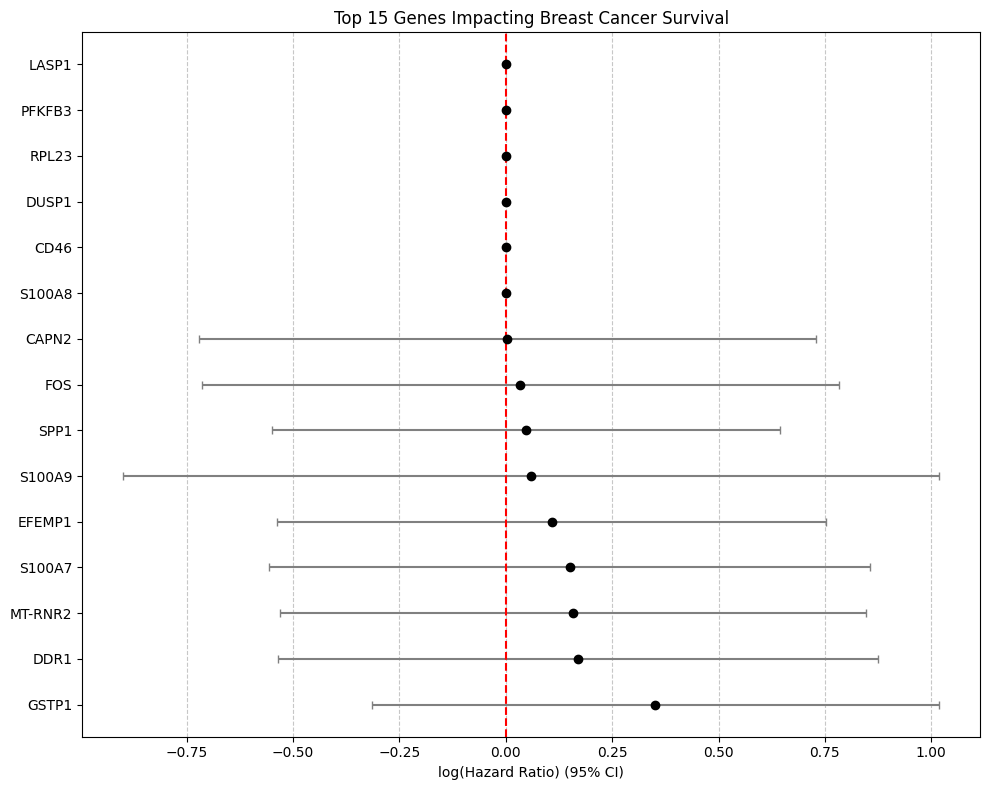

In [26]:
#ploting forest plot 

summary = best_model.summary


important_genes = summary.sort_values(by="coef", ascending=False).head(15)


plt.figure(figsize=(10, 8))
y_range = range(len(important_genes))


plt.errorbar(important_genes['coef'], y_range, 
             xerr=[important_genes['coef'] - important_genes['coef lower 95%'], 
                   important_genes['coef upper 95%'] - important_genes['coef']],
             fmt='o', color='black', ecolor='gray', capsize=3)

plt.yticks(y_range, important_genes.index)


plt.axvline(x=0, color='red', linestyle='--')

plt.title("Top 15 Genes Impacting Breast Cancer Survival")
plt.xlabel("log(Hazard Ratio) (95% CI)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Kaplan-Meier (KM) curve

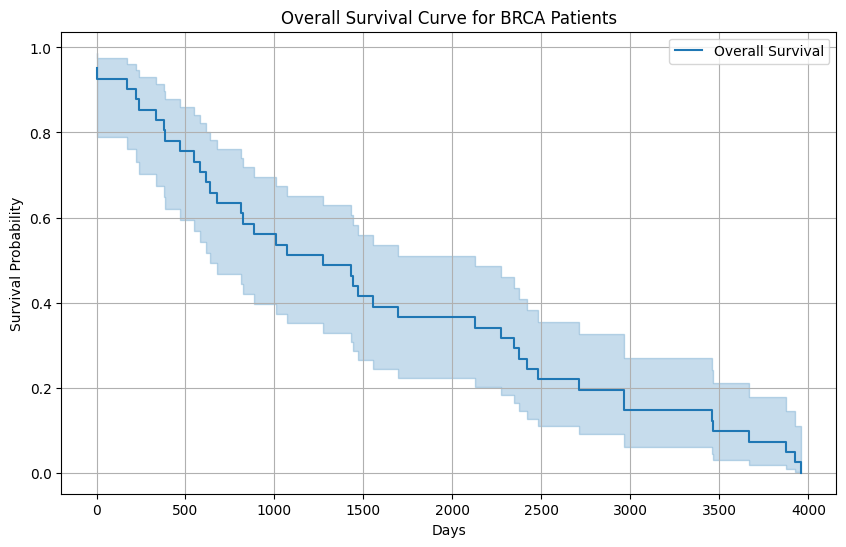

In [27]:
# 1. Initialize the fitter
kmf = KaplanMeierFitter()

# 2. Fit the data (Time and Event)
kmf.fit(durations=final_df['time'], event_observed=final_df['event'], label='Overall Survival')

# 3. Plot it
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()

plt.title('Overall Survival Curve for BRCA Patients')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

Comparing two genes with kmp curve

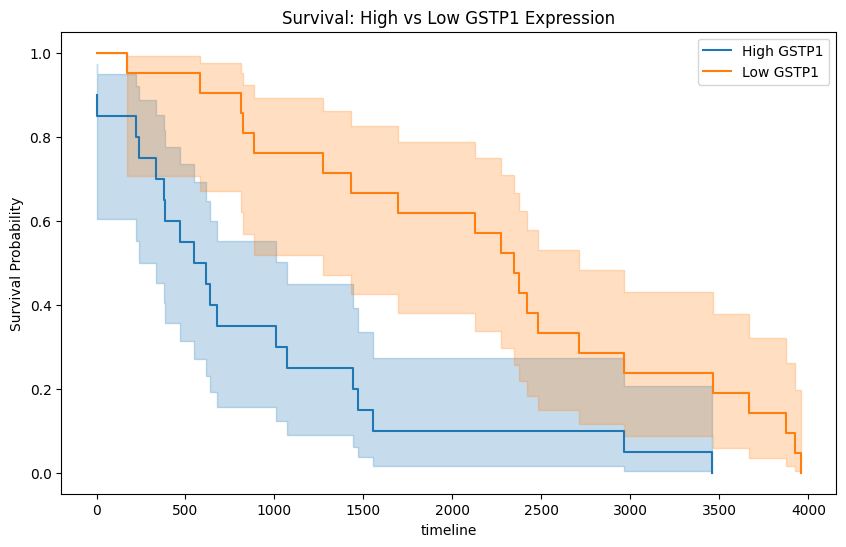

In [28]:
# 1. Split the data based on the median (middle) value of GSTP1
median_gstp1 = X_reduced['GSTP1'].median()
high_gstp1 = (X_reduced['GSTP1'] > median_gstp1)
low_gstp1 = (X_reduced['GSTP1'] <= median_gstp1)

# 2. Setup the plot
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# 3. Fit and Plot "High" group
kmf.fit(final_df['time'][high_gstp1], final_df['event'][high_gstp1], label='High GSTP1')
kmf.plot_survival_function(ax=ax)

# 4. Fit and Plot "Low" group
kmf.fit(final_df['time'][low_gstp1], final_df['event'][low_gstp1], label='Low GSTP1')
kmf.plot_survival_function(ax=ax)

plt.title('Survival: High vs Low GSTP1 Expression')
plt.ylabel('Survival Probability')
plt.show()

In [29]:
# Extract the gene names as a clean Python list
top_gene_list = top_genes.index.tolist()

print(top_gene_list)

['CD44', 'GSTP1', 'IFITM3', 'GPRC5A', 'SCGB1B2P', 'CRYBG1', 'IGHG3', 'DDR1', 'MT-RNR2', 'IGSF1', 'S100A7', 'RPL12', 'TNC', 'EFEMP1', 'PBX1', 'S100A11', 'CD81', 'S100A9', 'SPP1', 'FOS']


### Univariate Cox Regression.


In [30]:


# Assume top_gene_list has your 10 genes from LASSO
for gene in top_gene_list:
    print(f"\n--- Analyzing Gene: {gene} ---")
    
    # 1. Create a temporary table with ONLY this gene and survival info
    # We use [[gene]] to keep it as a DataFrame
    df_temp = X_reduced[[gene]].copy()
    df_temp['time'] = y_time
    df_temp['event'] = y_event
    
    # 2. Initialize and Fit
    cph = CoxPHFitter()
    
    try:
        cph.fit(df_temp, duration_col='time', event_col='event')
        
        # 3. Print the important stats
        hr = cph.hazard_ratios_[gene]
        p_val = cph.summary.loc[gene, 'p']
        c_index = cph.concordance_index_
        
        print(f"Hazard Ratio: {hr:.2f}")
        print(f"P-value: {p_val:.4f}")
        print(f"C-index (Accuracy): {c_index:.3f}")
        
    except Exception as e:
        print(f"Could not fit model for {gene}: {e}")


--- Analyzing Gene: CD44 ---
Hazard Ratio: 0.53
P-value: 0.0052
C-index (Accuracy): 0.653

--- Analyzing Gene: GSTP1 ---
Hazard Ratio: 1.72
P-value: 0.0051
C-index (Accuracy): 0.688

--- Analyzing Gene: IFITM3 ---
Hazard Ratio: 0.47
P-value: 0.0045
C-index (Accuracy): 0.642

--- Analyzing Gene: GPRC5A ---
Hazard Ratio: 0.61
P-value: 0.0033
C-index (Accuracy): 0.654

--- Analyzing Gene: SCGB1B2P ---
Hazard Ratio: 0.63
P-value: 0.0403
C-index (Accuracy): 0.620

--- Analyzing Gene: CRYBG1 ---
Hazard Ratio: 0.78
P-value: 0.1465
C-index (Accuracy): 0.538

--- Analyzing Gene: IGHG3 ---
Hazard Ratio: 0.81
P-value: 0.0138
C-index (Accuracy): 0.590

--- Analyzing Gene: DDR1 ---
Hazard Ratio: 0.99
P-value: 0.9648
C-index (Accuracy): 0.482

--- Analyzing Gene: MT-RNR2 ---
Hazard Ratio: 1.33
P-value: 0.3126
C-index (Accuracy): 0.559

--- Analyzing Gene: IGSF1 ---
Hazard Ratio: 0.93
P-value: 0.2703
C-index (Accuracy): 0.601

--- Analyzing Gene: S100A7 ---
Hazard Ratio: 1.06
P-value: 0.4284
C-index

### C-Index


In [31]:
# 1. Prepare the multivariate data (All 10 genes at once)
df_multivariate = X_reduced[top_gene_list].copy()
df_multivariate['time'] = y_time
df_multivariate['event'] = y_event

# 2. Fit the model
cph_final = CoxPHFitter()
cph_final.fit(df_multivariate, duration_col='time', event_col='event')

# 3. Get the C-Index
final_cindex = cph_final.concordance_index_
print(f" Final Multivariate C-Index: {final_cindex:.3f}")

 Final Multivariate C-Index: 0.873


### Cross Validation 5 fold

In [32]:
# 1. Setup the "Stress Test" (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
c_indices = []

# 2. Manual Loop through the folds
for train_idx, test_idx in kf.split(df_multivariate):
    # Split the data
    train_df = df_multivariate.iloc[train_idx]
    test_df = df_multivariate.iloc[test_idx]
    
    # Train the model on 80% of patients
    cph_fold = CoxPHFitter(penalizer=0.1)
    cph_fold.fit(train_df, duration_col='time', event_col='event')
    
    # Test the model on the remaining 20%
    score = cph_fold.concordance_index_
    c_indices.append(score)

# 3. The Moment of Truth
print(f" Real C-Indices for each fold: {c_indices}")
print(f" Final Average Accuracy: {np.mean(c_indices):.3f}")

 Real C-Indices for each fold: [np.float64(0.8929292929292929), np.float64(0.9108159392789373), np.float64(0.8519924098671727), np.float64(0.8821292775665399), np.float64(0.8916349809885932)]
 Final Average Accuracy: 0.886


In [35]:

final_df

,Patient_ID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6,Time,Event
0,TCGA-BH-A209,2044,27,3098,1851,1891,1754,5515,5997,4661,...,42,0,0,0,671,0,17,37,3959.0,1
1,TCGA-B6-A0IH,6786,14,1381,2134,628,433,5024,2068,1462,...,12,0,1,0,517,0,16,15,2965.0,1
2,TCGA-D8-A1XC,402,1,1146,1236,264,122,532,1616,3909,...,1,0,0,1,419,0,0,19,377.0,1
3,TCGA-EW-A1P8,5262,17,1908,795,1045,1055,696,3727,2470,...,14,0,0,0,304,0,6,32,239.0,1
4,TCGA-BH-A1F6,7064,1899,2680,1626,527,1235,27487,3534,4535,...,42,0,1,2,645,0,12,7,2965.0,1
5,TCGA-E9-A1N6,3106,771,1525,887,249,833,4736,1365,1918,...,13,0,0,0,295,0,13,10,678.0,1
6,TCGA-B6-A0IC,1100,1,2200,2375,779,284,103,2047,4247,...,58,0,0,0,330,0,8,39,0.0,1
7,TCGA-BH-A1EW,2690,27,2435,2226,945,571,4785,1725,1871,...,20,0,0,0,729,0,13,7,1694.0,1
8,TCGA-BH-A18V,3116,817,1408,954,125,461,2454,1871,1038,...,26,0,0,0,253,0,16,25,1556.0,1
9,TCGA-AC-A23H,7324,231,1806,1385,337,470,13491,3061,2356,...,31,0,0,0,498,0,4,6,0.0,1


In [41]:
output_dir = 'C:/Users/abrup/Desktop/Project/survival-analysis/data/processed'
top_gene_names = top_genes.index.tolist()
final_df=X_scaled[top_gene_names].copy()
final_df['time']=y_time
final_df['event']=y_event
final_df.reset_index(inplace=True)
final_df.rename(columns={'index': 'Patient_ID'}, inplace=True)
print(f"Final DataFrame created with {len(top_gene_names)} genes.")
display(final_df.head())
file_path = os.path.join(output_dir, 'top_20_genes_survival_data.csv')
final_df.to_csv(file_path, index=False)

print(f" Success! Your processed data is saved at: {file_path}")
print(f" Columns saved: Patient_ID, {len(top_gene_names)} Genes, Time, Event")

Final DataFrame created with 20 genes.


,Patient_ID,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,...,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS,time,event
0,0,0.467144,-0.409501,1.112887,0.791900,5.363893,0.888832,2.187349,-1.115790,-0.524356,...,-0.033789,0.548173,1.310858,0.991080,0.397376,0.458505,0.518122,-0.880487,3959.0,1
1,1,0.454776,-0.159768,-0.303420,-0.371377,0.263928,-0.110478,0.931092,-0.699474,-1.548765,...,-0.583797,-0.177882,0.779818,0.407760,0.103374,-0.245938,-1.623564,-1.033991,2965.0,1
2,2,0.977865,1.072303,-1.914388,0.795906,-0.381069,-2.432660,-1.613441,0.446688,-0.730537,...,-2.203938,-2.010211,0.563656,-2.442809,-2.240439,-1.229013,0.239873,-0.251100,377.0,1
3,3,-1.244080,1.409944,-0.488531,-0.538240,-0.998113,0.456657,0.348532,0.326569,-0.914706,...,2.248809,1.157220,-1.824979,0.427381,-0.510680,1.114703,2.228154,0.254938,239.0,1
4,4,0.950066,0.596614,0.382809,-0.451939,0.065328,0.878355,-0.576284,-0.898128,1.137397,...,1.165954,1.734998,0.095166,0.359642,1.182477,0.291822,-0.216480,0.523495,2965.0,1


 Success! Your processed data is saved at: C:/Users/abrup/Desktop/Project/survival-analysis/data/processed\top_20_genes_survival_data.csv
 Columns saved: Patient_ID, 20 Genes, Time, Event


In [43]:
df=pd.read_csv('C:/Users/abrup/Desktop/Project/survival-analysis/data/processed/top_20_genes_survival_data.csv')

In [44]:
df

,Patient_ID,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,...,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS,time,event
0,0,0.467144,-0.409501,1.112887,0.791900,5.363893,0.888832,2.187349,-1.115790,-0.524356,...,-0.033789,0.548173,1.310858,0.991080,0.397376,0.458505,0.518122,-0.880487,3959.0,1
1,1,0.454776,-0.159768,-0.303420,-0.371377,0.263928,-0.110478,0.931092,-0.699474,-1.548765,...,-0.583797,-0.177882,0.779818,0.407760,0.103374,-0.245938,-1.623564,-1.033991,2965.0,1
2,2,0.977865,1.072303,-1.914388,0.795906,-0.381069,-2.432660,-1.613441,0.446688,-0.730537,...,-2.203938,-2.010211,0.563656,-2.442809,-2.240439,-1.229013,0.239873,-0.251100,377.0,1
3,3,-1.244080,1.409944,-0.488531,-0.538240,-0.998113,0.456657,0.348532,0.326569,-0.914706,...,2.248809,1.157220,-1.824979,0.427381,-0.510680,1.114703,2.228154,0.254938,239.0,1
4,4,0.950066,0.596614,0.382809,-0.451939,0.065328,0.878355,-0.576284,-0.898128,1.137397,...,1.165954,1.734998,0.095166,0.359642,1.182477,0.291822,-0.216480,0.523495,2965.0,1
5,5,-0.660981,0.255809,-1.116267,-1.179336,-0.446866,0.434647,0.440220,-0.432324,-1.151923,...,0.209361,0.630672,-0.982226,-1.294848,-0.085014,0.066798,-0.625048,0.490977,678.0,1
6,6,-1.582673,0.505526,-0.256127,-0.704783,0.157511,-2.223726,-1.764151,1.317943,0.750777,...,-2.887190,1.005395,0.051465,-0.791638,-0.687300,-1.625911,1.181663,-1.051815,0.0,1
7,7,0.290030,-1.100307,0.588709,1.159825,-0.693095,0.145943,0.289372,0.347873,0.355432,...,-0.055182,-0.131385,0.878472,-0.026486,-0.892263,0.511120,-0.043040,-0.545343,1694.0,1
8,8,-0.601955,0.938176,-0.056820,-1.027843,0.606642,-0.279523,-0.284116,-0.952931,-0.069602,...,-0.245306,0.008847,-1.925223,-0.378981,0.475846,0.241568,-1.060051,1.624169,1556.0,1
9,9,0.470737,0.681711,0.132223,-1.037879,1.621227,0.935267,-0.317123,-0.602574,1.170778,...,0.628081,1.183598,0.242561,-0.285534,0.851973,0.751666,-0.723419,0.597312,0.0,1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Patient_ID  41 non-null     int64  
 1   CD44        41 non-null     float64
 2   GSTP1       41 non-null     float64
 3   IFITM3      41 non-null     float64
 4   GPRC5A      41 non-null     float64
 5   SCGB1B2P    41 non-null     float64
 6   CRYBG1      41 non-null     float64
 7   IGHG3       41 non-null     float64
 8   DDR1        41 non-null     float64
 9   MT-RNR2     41 non-null     float64
 10  IGSF1       41 non-null     float64
 11  S100A7      41 non-null     float64
 12  RPL12       41 non-null     float64
 13  TNC         41 non-null     float64
 14  EFEMP1      41 non-null     float64
 15  PBX1        41 non-null     float64
 16  S100A11     41 non-null     float64
 17  CD81        41 non-null     float64
 18  S100A9      41 non-null     float64
 19  SPP1        41 non-null     flo

In [46]:
df.head()

,Patient_ID,CD44,GSTP1,IFITM3,GPRC5A,SCGB1B2P,CRYBG1,IGHG3,DDR1,MT-RNR2,...,TNC,EFEMP1,PBX1,S100A11,CD81,S100A9,SPP1,FOS,time,event
0,0,0.467144,-0.409501,1.112887,0.791900,5.363893,0.888832,2.187349,-1.115790,-0.524356,...,-0.033789,0.548173,1.310858,0.991080,0.397376,0.458505,0.518122,-0.880487,3959.0,1
1,1,0.454776,-0.159768,-0.303420,-0.371377,0.263928,-0.110478,0.931092,-0.699474,-1.548765,...,-0.583797,-0.177882,0.779818,0.407760,0.103374,-0.245938,-1.623564,-1.033991,2965.0,1
2,2,0.977865,1.072303,-1.914388,0.795906,-0.381069,-2.432660,-1.613441,0.446688,-0.730537,...,-2.203938,-2.010211,0.563656,-2.442809,-2.240439,-1.229013,0.239873,-0.251100,377.0,1
3,3,-1.244080,1.409944,-0.488531,-0.538240,-0.998113,0.456657,0.348532,0.326569,-0.914706,...,2.248809,1.157220,-1.824979,0.427381,-0.510680,1.114703,2.228154,0.254938,239.0,1
4,4,0.950066,0.596614,0.382809,-0.451939,0.065328,0.878355,-0.576284,-0.898128,1.137397,...,1.165954,1.734998,0.095166,0.359642,1.182477,0.291822,-0.216480,0.523495,2965.0,1
